<a href="https://colab.research.google.com/github/azhgh22/Monet_Style_Generator/blob/main/notebooks/run.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Set Env**

In [1]:
%%capture
from google.colab import drive
drive.mount('/content/drive')

from google.colab import userdata
token = userdata.get('GITHUB_TOKEN')
user_name = userdata.get('GITHUB_USERNAME')
mail = userdata.get('GITHUB_MAIL')

!git config --global user.name "{user_name}"
!git config --global user.email "{mail}"
!git clone https://{token}@github.com/azhgh22/Monet_Style_Generator.git

# **Imports**

In [2]:
import sys
import os

# Add the root directory of the cloned repository to the Python path
sys.path.append('/content/Monet_Style_Generator')

import importlib
import preprocessing.custom_dataset as custom_dataset_module
import preprocessing.train_test_split as tts_module
import preprocessing.dataset_assembly as ds_assembly_module
importlib.reload(custom_dataset_module)
importlib.reload(tts_module)
importlib.reload(ds_assembly_module)
from preprocessing.custom_dataset import CustomDataset
from preprocessing.dataset_assembly import DatasetAssembly
from preprocessing.train_test_split import TrainTestSplit
from pathlib import Path
from torch.utils.data import DataLoader

# **Read Data and Split data**

In [3]:
train, val, test = TrainTestSplit("/content/Monet_Style_Generator/data/photo_jpg/").split(0.7,0.15,0.15)

In [4]:
monet_pictures = list(Path("/content/Monet_Style_Generator/data/monet_jpg/").glob('*.jpg'))

In [5]:
# create datasets
train_part = CustomDataset(train)
val_dataset = CustomDataset(val)
test_dataset = CustomDataset(test)

monet_dataset = CustomDataset(monet_pictures)

train_dataset = DatasetAssembly(train_part, monet_dataset)

In [6]:

import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
from torchvision.utils import make_grid

def show_img(x: torch.Tensor):
  x = x.detach().cpu()
  x = x.permute(1, 2, 0)

  plt.imshow(x)
  plt.axis("off")
  plt.show()

# **Data Loaders**

In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=100,
    shuffle=True,
)

val_loader = DataLoader(
    train_dataset,
    batch_size=100,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=100,
    shuffle=True,
  )

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

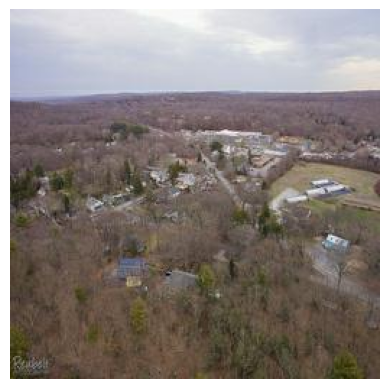

In [10]:
show_img(train_dataset[0][0])

In [12]:
img_tenzor = train_dataset[0][0]

In [13]:
img_tenzor.shape

torch.Size([3, 256, 256])

In [33]:
import models.GAN.generator_models.resnet_gen as res_gen
import models.GAN.discriminator_models.patchgan as res_gen
importlib.reload(res_gen)
from models.GAN.generator_models.resnet_gen import ResnetGenerator
from models.GAN.discriminator_models.patchgan import PatchGANDiscriminator

In [34]:
gen = ResnetGenerator()
gen_img = gen.forward(img_tenzor)

In [35]:
patch_gan = PatchGANDiscriminator()

In [36]:
disc = patch_gan.forward(gen_img)

In [37]:
disc.shape

torch.Size([1, 30, 30])